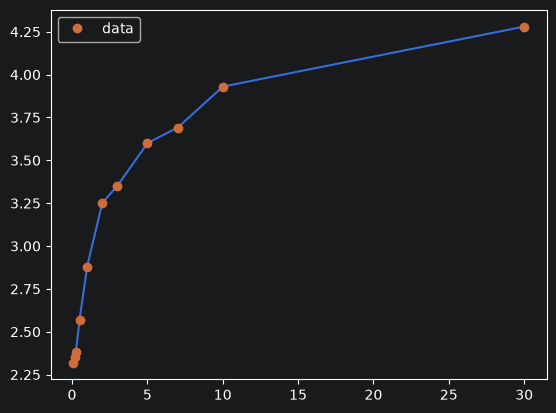

In [25]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import urllib3
import datetime
from datetime import timedelta
import matplotlib.pyplot as plt

urllib3.disable_warnings()

latest_business_day = datetime.date.today() - timedelta(days=1)
# print(latest_business_day)

start_date = '2026-10-02'
end_date = '2026-10-02'

# print(latest_business_day)

url = f'https://www.bankofcanada.ca/valet/observations/TB.CDN.30D.MID%2CTB.CDN.60D.MID%2CTB.CDN.90D.MID%2CTB.CDN.180D.MID%2CTB.CDN.1Y.MID/csv?start_date={start_date}&end_date={end_date}'
response = requests.get(url, verify=False)

f = response.text.split('"OBSERVATIONS"')[1]

rates_t_bills = pd.read_csv(StringIO(f))

rates_t_bills = rates_t_bills.rename(
    columns={'date': 'Date', 'TB.CDN.30D.MID': '1M', 'TB.CDN.60D.MID': '2M', 'TB.CDN.90D.MID': '3M',
             'TB.CDN.180D.MID': '6M', 'TB.CDN.1Y.MID': '1Y'})

rates_t_bills = rates_t_bills[['Date', '1M', '2M', '3M', '6M', '1Y']]

rates_t_bills.set_index('Date', inplace=True)

# # print(rates_t_bills)
#got the benchmark bond yield group from VALET API GROUPS script. Used that on the BoC Valet API groups url generator to get url below then modified it.

url_t_bonds = f'https://www.bankofcanada.ca/valet/observations/group/bond_yields_benchmark/csv?start_date={start_date}&end_date={end_date}'
response_t_bonds = requests.get(url_t_bonds, verify=False)

f = response_t_bonds.text.split('"OBSERVATIONS"')[1]

rates_t_bonds = pd.read_csv(StringIO(f))

rates_t_bonds = rates_t_bonds.rename(
    columns={'date': 'Date', 'BD.CDN.2YR.DQ.YLD': '2Y', 'BD.CDN.3YR.DQ.YLD': '3Y', 'BD.CDN.5YR.DQ.YLD': '5Y',
             'BD.CDN.7YR.DQ.YLD': '7Y', 'BD.CDN.10YR.DQ.YLD': '10Y', 'BD.CDN.LONG.DQ.YLD': '30Y+',
             'BD.CDN.RRB.DQ.YLD': 'Real-Return'})

rates_t_bonds.set_index('Date', inplace=True)

# # print(rates_t_bonds)

rates = pd.merge(rates_t_bills, rates_t_bonds, on='Date')
rates.drop('Real-Return', axis=1, inplace=True)
# print(rates)
rates = rates.T
# print(rates)
rates = rates.reset_index()
# print(rates.columns)
rates = rates.rename(columns={rates.columns[0]: 'Label', rates.columns[1]: 'Yield'})
rates['Term'] = ['0.083', '0.167', '0.25', '0.50', '1.00', '2.00', '3.00', '5.00', '7.00', '10.00', '30.00']
rates['Term'] = rates['Term'].astype(float)
# print(rates)
rates['Yield'].interpolate(method='linear', inplace=False)
# print(rates)
# rates.plot(x='Label', y='Yield', kind='line')

curve_terms = rates['Term']
curve_yields = rates['Yield']
interp_terms = np.linspace(0.083, 30, num=10000)
interp_yields = np.interp(interp_terms, curve_terms, curve_yields)
plt.plot(interp_terms, interp_yields)
plt.plot(curve_terms, curve_yields, 'o', label='data')
plt.legend(loc='best')
plt.show()


def curve_output(term):
    if 0 <= term <= 30:
        interpolated_yield = np.interp(term, rates['Term'], rates['Yield'])
        return float(interpolated_yield)
    else:
        print("Nope, try again between 0 and 30")
        return None

In [26]:
 print(rates)

Date Label  Yield    Term
0       1M   2.32   0.083
1       2M   2.35   0.167
2       3M   2.38   0.250
3       6M   2.57   0.500
4       1Y   2.88   1.000
5       2Y   3.25   2.000
6       3Y   3.35   3.000
7       5Y   3.60   5.000
8       7Y   3.69   7.000
9      10Y   3.93  10.000
10    30Y+   4.28  30.000


In [27]:
def discount_factor(yield_rate,term):
    if yield_rate > 1:
        yield_rate = yield_rate/100
        denominator = (1 + yield_rate) ** term
        discount = 1/denominator
        return discount
    else:
        denominator = (1 + yield_rate) ** term
        discount = 1/denominator
        return discount

In [28]:
#note to self - improve this later - use vectorized operation or lambda function.
for x in range(len(rates)):
    rates.loc[x, 'Discount'] = discount_factor(yield_rate=rates.loc[x, 'Yield'], term=rates.loc[x, 'Term'])

In [29]:
print(rates)

Date Label  Yield    Term  Discount
0       1M   2.32   0.083  0.998098
1       2M   2.35   0.167  0.996128
2       3M   2.38   0.250  0.994137
3       6M   2.57   0.500  0.987392
4       1Y   2.88   1.000  0.972006
5       2Y   3.25   2.000  0.938037
6       3Y   3.35   3.000  0.905876
7       5Y   3.60   5.000  0.837917
8       7Y   3.69   7.000  0.775965
9      10Y   3.93  10.000  0.680128
10    30Y+   4.28  30.000  0.284426


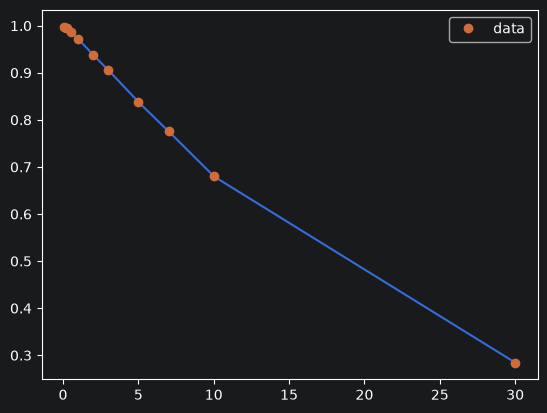

In [30]:
discount_factor_terms = rates['Term']
discount_factor_nodes = rates['Discount']
interp_discount_factor_terms = np.linspace(0.083, 30, num=10000)
interp_discount_factors = np.interp(interp_discount_factor_terms, discount_factor_terms, discount_factor_nodes)
plt.plot(interp_discount_factor_terms, interp_discount_factors)
plt.plot(discount_factor_terms, discount_factor_nodes, 'o', label='data')
plt.legend(loc='best')
plt.show()

In [31]:
face_value = 1000
coupon_rate = 3
coupon_amount = coupon_rate/100 * face_value
maturity_years = 5


In [32]:
total_present_value_coupons = 0
present_value_principal = 0

for x in range(maturity_years):
    pv_coupon = coupon_amount * discount_factor(curve_output(x+1), x+1)
    total_present_value_coupons = total_present_value_coupons + pv_coupon
    print(pv_coupon)

present_value_principal = face_value * discount_factor(curve_output(maturity_years), maturity_years)
print(present_value_principal)
bond_price = total_present_value_coupons + present_value_principal
print("The price of the bond is {bond_price}".format(bond_price=bond_price))


29.160186625194406
28.14110418657552
27.176267695376172
26.168541286471775
25.13752280919788
837.9174269732626
The price of the bond is 973.7010495760784


In [33]:
sum_macaulay_coupons = 0

for x in range(maturity_years):
    pv_coupon = coupon_amount * discount_factor(curve_output(x+1), x+1)
    macaulay_coupon = (x+1) * pv_coupon
    sum_macaulay_coupons = sum_macaulay_coupons + macaulay_coupon


present_value_principal = face_value * discount_factor(curve_output(maturity_years), maturity_years)

macaulay_principal = present_value_principal * maturity_years

macaulay_numerator = sum_macaulay_coupons + macaulay_principal

bond_price = total_present_value_coupons + present_value_principal

macaulay_duration = macaulay_numerator / bond_price

print("The MacDur is {macaulay_duration}".format(macaulay_duration=macaulay_duration))


The MacDur is 4.710809456495581


In [34]:
modified_duration = macaulay_duration / (1 + (curve_output(maturity_years)/100))

print(macaulay_duration)
print(modified_duration)

4.710809456495581
4.547113374995734


In [35]:
dv01 = bond_price * modified_duration * 0.0001

print("The DV01 of the bond is ${dv01}".format(dv01=dv01))

The DV01 of the bond is $0.4427529065774771
